In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================

import os, re, cv2, copy, time, random, gc, math, hashlib, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
USE_AMP = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

seed_everything(SEED)
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

Device: cuda | AMP: True


In [2]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================

class CFG:
    data_root     = "/teamspace/studios/this_studio/EndoscopicBladderTissue"
    aug_root      = "/teamspace/studios/this_studio/Augmented Data"
    aug_manifest  = "/teamspace/studios/this_studio/Augmented Data/augmented_only_manifest.csv"
    cache_dir     = "feature_cache"
    cache_version = "v2"              # ← reuse existing cache!
    model_dir     = "saved_models"

    class_names   = ['HGC', 'LGC', 'Normal']
    num_classes   = 3

    image_resize          = 512
    clahe_clip            = 1.5
    clahe_grid            = (16, 16)
    patch_scales          = [96, 128, 192]
    patch_output_size     = 224
    patch_stride_frac     = 0.5
    min_tissue            = 0.40
    max_bright            = 245
    min_bright            = 15
    min_sat               = 10
    min_focus             = 8.0
    top_quality_frac      = 0.85
    max_patches_per_image = 60

    feat_batch    = 128
    patch_batch_target = 512
    feat_dim      = 1024

    # CLAM
    mil_hidden      = 512
    mil_dropout     = 0.25
    clam_k_sample   = 10
    feat_noise_std  = 0.02
    feat_drop_p     = 0.1
    n_att_heads     = 4

    # Losses
    bag_loss_w      = 1.0
    inst_loss_w     = 0.20
    hier_loss_w     = 0.10
    ordinal_loss_w  = 0.10            # ← NEW
    focal_gamma     = 3.0             # ← was 2.5
    hgc_weight_boost = 2.5            # ← was 2.0
    label_smooth    = 0.05

    # MixUp
    mixup_alpha     = 0.3
    mixup_prob      = 0.20
    mixup_cap_frac  = 0.15

    # Balanced sampling
    balanced_sampling = True           # ← NEW

    # Two-stage training
    epochs             = 50            # Stage 1
    hard_mine_epochs   = 15            # ← NEW: Stage 2
    hard_mine_frac     = 0.40          # ← NEW
    hard_mine_lr_factor = 0.2          # ← NEW
    patience           = 12
    lr                 = 1e-4
    wd                 = 5e-5
    grad_clip          = 1.0
    warmup_epochs      = 3
    max_patches_train  = 200
    max_patches_test   = 400

    # Ensemble + inference
    n_ensemble         = 3
    ensemble_dropouts  = [0.20, 0.25, 0.30]
    use_tta            = True
    tta_rounds         = 3
    use_mc_dropout     = True          # ← NEW

    class_weights = None

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)
LABEL_MAP  = {'HGC': 'HGC', 'LGC': 'LGC', 'NST': 'Normal', 'NTL': 'Normal'}
CANCER_CLASSES = {0, 1}
NORMAL_CLASSES = {2}

os.makedirs(CFG.cache_dir, exist_ok=True)
os.makedirs(CFG.model_dir, exist_ok=True)
print("✓ Config v3 loaded (ordinal + hard-mining + balanced + MC-dropout)")

✓ Config v3 loaded (ordinal + hard-mining + balanced + MC-dropout)


In [3]:
# ============================================================
# CELL 3: LOAD ORIGINAL DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING ORIGINAL DATASET")
print("="*60)

records = []
pattern = re.compile(r'pt[_]?0*(\d+)')

for label in os.listdir(CFG.data_root):
    class_path = os.path.join(CFG.data_root, label)
    if not os.path.isdir(class_path):
        continue
    if label not in LABEL_MAP:
        print(f"  ⚠ Skipping unknown folder: {label}")
        continue
    for img_name in os.listdir(class_path):
        match = pattern.search(img_name)
        if match:
            records.append({
                "path":           os.path.join(class_path, img_name),
                "label":          LABEL_MAP[label],
                "original_label": label,
                "patient":        int(match.group(1)),
                "filename":       img_name,
                "is_augmented":   False,
                "aug_mode":       "none",
            })

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)

print(f"Total original images : {len(df)}")
print(f"Total patients        : {df.patient.nunique()}")
print(f"Classes               : {CFG.class_names}")

class_counts = df['label'].value_counts()
total = len(df)
print(f"\nClass distribution:")
for cls in CFG.class_names:
    n = class_counts.get(cls, 0)
    print(f"  {cls}: {n} ({100*n/total:.1f}%)")

PATIENTS   = sorted(df.patient.unique())
N_PATIENTS = len(PATIENTS)

print(f"\n{'Patient':<10} {'#Imgs':<8} {'Distribution'}")
print("-"*65)
for pid in PATIENTS:
    pdf    = df[df.patient == pid]
    counts = Counter(pdf.label.values)
    dist   = ", ".join(f"{k}:{v}" for k, v in sorted(counts.items()))
    print(f"  P{pid:<8} {len(pdf):<8} {dist}")

print(f"\n✓ {N_PATIENTS} patients, {len(df)} original images")


LOADING ORIGINAL DATASET
Total original images : 1713
Total patients        : 14
Classes               : ['HGC', 'LGC', 'Normal']

Class distribution:
  HGC: 469 (27.4%)
  LGC: 647 (37.8%)
  Normal: 597 (34.9%)

Patient    #Imgs    Distribution
-----------------------------------------------------------------
  P1        491      HGC:88, LGC:128, Normal:275
  P2        302      HGC:75, LGC:112, Normal:115
  P3        172      HGC:102, LGC:26, Normal:44
  P4        234      HGC:110, LGC:79, Normal:45
  P5        175      HGC:46, LGC:70, Normal:59
  P6        122      HGC:40, LGC:76, Normal:6
  P7        28       HGC:8, LGC:14, Normal:6
  P8        57       LGC:45, Normal:12
  P9        9        LGC:9
  P10       51       LGC:51
  P11       46       LGC:11, Normal:35
  P12       19       LGC:19
  P13       3        LGC:3
  P14       4        LGC:4

✓ 14 patients, 1713 original images


In [ ]:
# ============================================================
# CELL 4: LOAD AUGMENTED DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING AUGMENTED DATASET")
print("="*60)

aug_df = pd.read_csv(CFG.aug_manifest)
print(f"Manifest rows    : {len(aug_df)}")
print(f"Manifest columns : {aug_df.columns.tolist()}")

print("\nBuilding file index from disk...")
aug_file_index = {}
for root, dirs, files in os.walk(CFG.aug_root):
    for fname in files:
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            aug_file_index[fname] = os.path.join(root, fname)
print(f"Indexed {len(aug_file_index)} image files")

FNAME_COL = None
for candidate in ['HLY', 'filename', 'aug_filename', 'file']:
    if candidate in aug_df.columns:
        FNAME_COL = candidate
        break
if FNAME_COL is None:
    for col in aug_df.columns:
        sample = str(aug_df[col].iloc[0])
        if sample.strip().endswith(('.png', '.jpg', '.jpeg')):
            FNAME_COL = col
            break
if FNAME_COL is None:
    raise ValueError(f"No filename column. Columns: {aug_df.columns.tolist()}")

print(f"Using filename column: '{FNAME_COL}'")

def resolve_aug_path(fname):
    fname = str(fname).strip()
    if fname in aug_file_index:
        return aug_file_index[fname]
    basename = os.path.basename(fname)
    if basename in aug_file_index:
        return aug_file_index[basename]
    return None

aug_df['path'] = aug_df[FNAME_COL].apply(resolve_aug_path)
missing = aug_df['path'].isna().sum()
aug_df  = aug_df[aug_df['path'].notna()].reset_index(drop=True)
print(f"Resolved: {len(aug_df)} | Missing: {missing}")

aug_df['label'] = aug_df['tissue type'].map(LABEL_MAP)
unmapped = aug_df['label'].isna().sum()
if unmapped:
    print(f"⚠ Dropping {unmapped} unmapped rows")
    aug_df = aug_df[aug_df['label'].notna()].copy()

aug_df['target']       = aug_df['label'].map(class_to_idx)
aug_df['is_augmented'] = True

if 'patient_id' in aug_df.columns:
    aug_df = aug_df.rename(columns={'patient_id': 'patient'})
if 'patient' not in aug_df.columns:
    raise ValueError(f"No patient column. Columns: {aug_df.columns.tolist()}")
aug_df['patient'] = aug_df['patient'].astype(int)

print(f"\nAugmented class distribution:")
for cls in CFG.class_names:
    print(f"  {cls}: {(aug_df['label'] == cls).sum()}")
print(f"\n✓ {len(aug_df)} augmented images ready")


LOADING AUGMENTED DATASET
Manifest rows    : 1676
Manifest columns : ['HLY', 'tissue type', 'imaging type', 'patient_id', 'is_augmented', 'aug_mode', 'source_filename', 'source_domain', 'source_abs_path', 'aug_abs_path', 'full_path', 'sub_dataset', 'abs_path']

Building file index from disk...
Indexed 1677 image files
Using filename column: 'HLY'
Resolved: 1676 | Missing: 0

Augmented class distribution:
  HGC: 469
  LGC: 647
  Normal: 560

✓ 1676 augmented images ready


In [ ]:
# ============================================================
# CELL 5: CLASS WEIGHTS (HGC boosted)
# ============================================================

weights = []
print(f"\nClass weights (HGC boost ×{CFG.hgc_weight_boost}):")
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    w     = total / (CFG.num_classes * max(count, 1))
    if cls == 'HGC':
        w *= CFG.hgc_weight_boost
    weights.append(w)
    print(f"  {cls}: {count} → weight={w:.3f}")

CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Tensor: {CFG.class_weights}")


Class weights (HGC boost ×2.5):
  HGC: 469 → weight=3.044
  LGC: 647 → weight=0.883
  Normal: 597 → weight=0.956
Tensor: tensor([3.0437, 0.8825, 0.9564], device='cuda:0')


In [6]:
# ============================================================
# CELL 6: LAB NORMALIZER + CLAHE
# ============================================================

class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, images_bgr):
        stats = {'L': [], 'a': [], 'b': []}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L', 'a', 'b']):
                stats[ch].append({
                    'm': lab[:,:,i].mean(), 's': lab[:,:,i].std() + 1e-6
                })
        self.ref = {
            ch: {
                'm': np.median([s['m'] for s in stats[ch]]),
                's': np.median([s['s'] for s in stats[ch]])
            } for ch in ['L', 'a', 'b']
        }
        return self

    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L', 'a', 'b']):
            c = lab[:,:,i]; sm, ss = c.mean(), c.std() + 1e-6
            lab[:,:,i] = np.clip(
                (c - sm) * (self.ref[ch]['s'] / ss) + self.ref[ch]['m'], 0, 255
            )
        lab = lab.astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid)
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    s = CFG.image_resize / max(h, w)
    if s != 1:
        img = cv2.resize(img, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA)
    if norm:
        img = norm.transform(img)
    return img


def fit_normalizer_excluding(exclude_pid=None):
    samples = []
    for pid in PATIENTS:
        if pid == exclude_pid:
            continue
        for fp in df[df.patient == pid].path.values[:12]:
            try:
                img = cv2.imread(fp)
                if img is not None:
                    h, w = img.shape[:2]
                    s = CFG.image_resize / max(h, w)
                    if s != 1:
                        img = cv2.resize(img, (int(w*s), int(h*s)))
                    samples.append(img)
            except:
                pass
    return LabNormalizer().fit(samples)


global_normalizer = fit_normalizer_excluding(exclude_pid=None)
print("✓ Global normalizer fitted")

✓ Global normalizer fitted


In [7]:
# ============================================================
# CELL 7: MULTI-SCALE PATCH EXTRACTION
# ============================================================

def compute_quality(patch_bgr):
    hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2].astype(np.float32)
    s = hsv[:,:,1].astype(np.float32)
    mask = (v < CFG.max_bright) & (v > CFG.min_bright) & (s > CFG.min_sat)
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG.min_tissue:
        return -1.0
    gray = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG.min_focus:
        return -1.0
    focus_norm   = min(focus / 100.0, 1.0)
    sat_std      = s[mask].std() / 50.0 if mask.sum() > 10 else 0
    sat_norm     = min(sat_std, 1.0)
    edges        = cv2.Canny(gray, 50, 150)
    edge_density = min(edges.sum() / (255.0 * edges.size) * 10, 1.0)
    return 0.3*tissue_frac + 0.3*focus_norm + 0.2*sat_norm + 0.2*edge_density


def extract_multiscale_patches(image_bgr, max_patches=None):
    if max_patches is None:
        max_patches = CFG.max_patches_per_image
    H, W = image_bgr.shape[:2]
    candidates = []
    cap = max_patches * 3
    for scale in CFG.patch_scales:
        if scale > min(H, W):
            continue
        stride = max(1, int(scale * CFG.patch_stride_frac))
        for y in range(0, H - scale + 1, stride):
            for x in range(0, W - scale + 1, stride):
                if len(candidates) >= cap:
                    break
                crop = image_bgr[y:y+scale, x:x+scale]
                q = compute_quality(crop)
                if q > 0:
                    resized = cv2.resize(crop, (CFG.patch_output_size, CFG.patch_output_size),
                                         interpolation=cv2.INTER_AREA)
                    candidates.append((resized, q, scale))
            if len(candidates) >= cap:
                break
    if not candidates:
        return [], [], []
    candidates.sort(key=lambda x: x[1], reverse=True)
    n_keep = max(1, int(len(candidates) * CFG.top_quality_frac))
    candidates = candidates[:n_keep][:max_patches]
    return [c[0] for c in candidates], [c[1] for c in candidates], [c[2] for c in candidates]


test_img = load_image(df.iloc[0].path, global_normalizer)
tp, _, _ = extract_multiscale_patches(test_img)
print(f"✓ Patch test: {test_img.shape} → {len(tp)} patches")
del tp, test_img; gc.collect()

✓ Patch test: (512, 512, 3) → 60 patches


0

In [8]:
# ============================================================
# CELL 8: DUAL BACKBONE
# ============================================================

def load_dinov2():
    print("  Loading DINOv2...")
    for model_name, dim in [('dinov2_vitb14', 768), ('dinov2_vits14', 384)]:
        try:
            model = torch.hub.load('facebookresearch/dinov2', model_name)
            model.eval()
            for p in model.parameters(): p.requires_grad = False
            print(f"  ✓ {model_name} — dim={dim}")
            return model.to(DEVICE), dim
        except Exception as e:
            print(f"  ⚠ {model_name} failed: {e}")
    try:
        model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
        model.eval()
        for p in model.parameters(): p.requires_grad = False
        print("  ✓ DINO ViT-S/16 fallback — dim=384")
        return model.to(DEVICE), 384
    except Exception as e:
        print(f"  ⚠ All DINO failed: {e}")
        return None, 0

def load_densenet():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    feat_dim = model.classifier.in_features
    model.classifier = nn.Identity()
    model.eval()
    for p in model.parameters(): p.requires_grad = False
    return model.to(DEVICE), feat_dim

print("Loading backbones...")
dino_model, dino_dim   = load_dinov2()
dense_model, dense_dim = load_densenet()
print(f"  ✓ DenseNet121 — dim={dense_dim}")

CFG.feat_dim = (dino_dim if dino_model else 0) + dense_dim
backbone_parts = []
if dino_model: backbone_parts.append(f"DINOv2({dino_dim})")
backbone_parts.append(f"DenseNet121({dense_dim})")
backbone_desc = " + ".join(backbone_parts)
print(f"\n✓ Feature dim: {CFG.feat_dim} | {backbone_desc}")

Loading backbones...
  Loading DINOv2...


Using cache found in /home/zeus/.cache/torch/hub/facebookresearch_dinov2_main
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  ✓ dinov2_vitb14 — dim=768
  ✓ DenseNet121 — dim=1024

✓ Feature dim: 1792 | DINOv2(768) + DenseNet121(1024)


In [9]:
# ============================================================
# CELL 9: FEATURE EXTRACTION (uses cache from v2 run)
# ============================================================

def bgr_to_tensor(patch_bgr):
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0

def _get_cache_key(path):
    key_str = f"{path}|{CFG.image_resize}|{CFG.patch_scales}|{CFG.max_patches_per_image}|{CFG.cache_version}"
    return hashlib.md5(key_str.encode()).hexdigest()

@torch.inference_mode()
def extract_dual_features(tensor_list):
    if not tensor_list:
        return torch.empty((0, CFG.feat_dim), dtype=torch.float16)

    all_feats = []
    for i in range(0, len(tensor_list), CFG.feat_batch):
        batch = torch.stack(tensor_list[i:i+CFG.feat_batch]).to(DEVICE, non_blocking=True)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD

        parts = []
        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
            if dino_model is not None:
                dino_out = dino_model(batch_norm)
                if isinstance(dino_out, dict):
                    dino_feats = dino_out.get('x_norm_clstoken', next(iter(dino_out.values())))
                else:
                    dino_feats = dino_out
                if dino_feats.dim() > 2:
                    dino_feats = dino_feats[:, 0, :]
                parts.append(dino_feats.float().cpu())
            parts.append(dense_model(batch_norm).float().cpu())
        all_feats.append(torch.cat(parts, dim=1))

    return torch.cat(all_feats, 0).half()

def extract_features_for_rows(row_df, desc="Extracting", norm=None, use_cache=True):
    results, skipped, cache_hits = [], 0, 0
    pending_tensors, pending_meta = [], []

    def flush_pending():
        nonlocal pending_tensors, pending_meta, results
        if not pending_tensors:
            return
        feats = extract_dual_features(pending_tensors)
        start = 0
        for meta in pending_meta:
            n_patches = meta['n_patches']
            feat_block = feats[start:start + n_patches]
            start += n_patches
            if meta['cache_path'] is not None:
                torch.save({'features': feat_block}, meta['cache_path'])
            results.append({
                'features': feat_block,
                'label': meta['label'],
                'label_name': meta['label_name'],
                'patient': meta['patient'],
                'path': meta['path'],
                'is_augmented': meta['is_augmented'],
                'aug_mode': meta['aug_mode'],
                'n_patches': feat_block.shape[0],
                'row_order': meta['row_order'],
            })
        pending_tensors = []
        pending_meta = []

    for row_order, (_, row) in enumerate(tqdm(row_df.iterrows(), total=len(row_df), desc=desc)):
        cache_path = None
        if use_cache:
            cache_key  = _get_cache_key(row.path)
            cache_path = os.path.join(CFG.cache_dir, f"{cache_key}.pt")
            if os.path.exists(cache_path):
                try:
                    cached = torch.load(cache_path, map_location='cpu')
                    results.append({
                        'features': cached['features'], 'label': int(row.target),
                        'label_name': row.label, 'patient': int(row.patient),
                        'path': row.path, 'is_augmented': bool(row.is_augmented),
                        'aug_mode': str(row.get('aug_mode', 'none')),
                        'n_patches': cached['features'].shape[0],
                        'row_order': row_order,
                    })
                    cache_hits += 1
                    continue
                except:
                    pass
        try:
            img = load_image(row.path, norm)
        except:
            skipped += 1
            continue
        patches, _, _ = extract_multiscale_patches(img)
        if not patches:
            skipped += 1
            continue
        tensors = [bgr_to_tensor(p) for p in patches]
        if len(tensors) > CFG.max_patches_per_image:
            idx = random.sample(range(len(tensors)), CFG.max_patches_per_image)
            tensors = [tensors[i] for i in sorted(idx)]
        pending_tensors.extend(tensors)
        pending_meta.append({
            'label': int(row.target),
            'label_name': row.label,
            'patient': int(row.patient),
            'path': row.path,
            'is_augmented': bool(row.is_augmented),
            'aug_mode': str(row.get('aug_mode', 'none')),
            'n_patches': len(tensors),
            'cache_path': cache_path,
            'row_order': row_order,
        })
        if len(pending_tensors) >= CFG.patch_batch_target:
            flush_pending()

    flush_pending()
    results.sort(key=lambda d: d['row_order'])

    if skipped: print(f"  ⚠ Skipped {skipped} images")
    if cache_hits: print(f"  ⚡ Cache hits: {cache_hits}/{len(row_df)}")
    return results

print("\n" + "="*60)
print("EXTRACTING FEATURES — ORIGINAL IMAGES")
print("="*60)
t0 = time.time()
orig_image_data = extract_features_for_rows(df, desc="Original", norm=global_normalizer)
print(f"✓ {len(orig_image_data)} original | {(time.time()-t0)/60:.1f} min")

print("\n" + "="*60)
print("EXTRACTING FEATURES — AUGMENTED IMAGES")
print("="*60)
t0 = time.time()
aug_image_data = extract_features_for_rows(aug_df, desc="Augmented", norm=global_normalizer)
print(f"✓ {len(aug_image_data)} augmented | {(time.time()-t0)/60:.1f} min")

def mem_gb(dl):
    return sum(d['features'].element_size() * d['features'].nelement() for d in dl) / 1e9

print(f"\nMemory: orig={mem_gb(orig_image_data):.2f}GB aug={mem_gb(aug_image_data):.2f}GB")

del dino_model, dense_model
torch.cuda.empty_cache(); gc.collect()
print("✓ Backbones freed")


EXTRACTING FEATURES — ORIGINAL IMAGES


Original:   0%|          | 3/1713 [00:00<04:59,  5.70it/s]

Original: 100%|██████████| 1713/1713 [10:26<00:00,  2.73it/s]


✓ 1713 original | 10.5 min

EXTRACTING FEATURES — AUGMENTED IMAGES


Augmented: 100%|██████████| 1676/1676 [10:16<00:00,  2.72it/s]


✓ 1676 augmented | 10.3 min

Memory: orig=0.37GB aug=0.36GB
✓ Backbones freed


In [10]:
# ============================================================
# CELL 10: LOSS FUNCTIONS (Focal + Hierarchical + Ordinal)
# ============================================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def hierarchical_loss(logits, label):
    """Binary cancer-vs-normal loss."""
    cancer_score = logits[0] + logits[1]
    normal_score = logits[2]
    binary_logit = torch.stack([cancer_score, normal_score]).unsqueeze(0)
    binary_target = torch.tensor(
        [0] if label.item() in CANCER_CLASSES else [1],
        dtype=torch.long, device=label.device
    )
    return F.cross_entropy(binary_logit, binary_target)


def ordinal_loss(logits, label):
    """
    Penalizes predictions proportional to ordinal distance.
    HGC(0) > LGC(1) > Normal(2) in severity.
    Predicting Normal when truth is HGC costs more than predicting LGC.
    """
    probs = F.softmax(logits, dim=0)
    severity = torch.arange(CFG.num_classes, dtype=torch.float32, device=logits.device)
    pred_severity = (probs * severity).sum()
    true_severity = severity[label]
    return (pred_severity - true_severity) ** 2


def compute_loss(output, label, class_weights=None, focal_criterion=None):
    """Combined: focal + hierarchical + ordinal + instance."""
    logits = output['logits'].unsqueeze(0)
    target = label.unsqueeze(0)

    if focal_criterion is not None:
        bag_loss = focal_criterion(logits, target)
    else:
        bag_loss = F.cross_entropy(logits, target, weight=class_weights,
                                   label_smoothing=CFG.label_smooth)

    hier = hierarchical_loss(output['logits'], label)
    ordi = ordinal_loss(output['logits'], label)

    total = (CFG.bag_loss_w    * bag_loss +
             CFG.hier_loss_w   * hier +
             CFG.ordinal_loss_w * ordi +
             CFG.inst_loss_w   * output['inst_loss'])
    return total


print("✓ Loss functions ready (focal + hierarchical + ordinal)")

✓ Loss functions ready (focal + hierarchical + ordinal)


In [11]:
# ============================================================
# CELL 11: CLAM MODEL (COMPLETE)
# ============================================================

class MultiHeadGatedAttention(nn.Module):
    def __init__(self, hidden, n_heads=4):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = hidden // 2 // n_heads
        self.att_nets = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, self.head_dim), nn.Tanh())
            for _ in range(n_heads)
        ])
        self.gate_nets = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, self.head_dim), nn.Sigmoid())
            for _ in range(n_heads)
        ])
        self.combine = nn.Linear(self.head_dim * n_heads, hidden // 2)

    def forward(self, h):
        heads = [a(h) * g(h) for a, g in zip(self.att_nets, self.gate_nets)]
        return self.combine(torch.cat(heads, dim=-1))


class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample, n_heads=CFG.n_att_heads):
        super().__init__()
        self.n_classes  = n_classes
        self.k_sample   = k_sample
        self.feat_noise = CFG.feat_noise_std
        self.feat_drop  = nn.Dropout(CFG.feat_drop_p)

        # Feature adapter — lightweight projection with residual
        self.adapter = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(feat_dim, feat_dim),
        )

        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.mh_attention = MultiHeadGatedAttention(hidden, n_heads)
        self.att_temp = nn.Parameter(torch.ones(n_classes))

        self.att_branches = nn.ModuleList([
            nn.Linear(hidden // 2, 1) for _ in range(n_classes)
        ])
        self.inst_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, 128), nn.GELU(),
                nn.Dropout(0.1), nn.Linear(128, 2)
            ) for _ in range(n_classes)
        ])
        self.bag_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden // 4),
                nn.GELU(),
                nn.Linear(hidden // 4, 1)
            ) for _ in range(n_classes)
        ])

    def _inst_loss(self, scores, h, classifier, k):
        N = scores.shape[0]
        k = min(k, N // 2, 8)
        if k < 1:
            return torch.tensor(0.0, device=h.device)
        top_idx = torch.topk(scores, k).indices
        bot_idx = torch.topk(scores, k, largest=False).indices
        feats   = torch.cat([h[top_idx], h[bot_idx]], dim=0)
        labels  = torch.cat([
            torch.ones(k, dtype=torch.long),
            torch.zeros(k, dtype=torch.long)
        ]).to(h.device)
        return F.cross_entropy(classifier(feats), labels)

    def forward(self, x, label=None):
        x = x.float()

        if self.training:
            x = x + torch.randn_like(x) * self.feat_noise
            x = self.feat_drop(x)

        # Adapter with residual connection
        x = x + self.adapter(x)

        h   = self.fc(x)
        att = self.mh_attention(h)

        logits     = []
        total_inst = torch.tensor(0.0, device=x.device)

        for c in range(self.n_classes):
            a_scores  = self.att_branches[c](att).squeeze(-1)
            a_scores  = a_scores / (self.att_temp[c].abs() + 0.1)
            a_weights = F.softmax(a_scores, dim=0)
            bag       = torch.sum(a_weights.unsqueeze(-1) * h, dim=0)
            logits.append(self.bag_classifiers[c](bag))

            if self.training and label is not None and label.item() == c:
                total_inst += self._inst_loss(
                    a_scores.detach(), h,
                    self.inst_classifiers[c], self.k_sample
                )

        return {'logits': torch.cat(logits), 'inst_loss': total_inst}


# Smoke test
_m = CLAM().to(DEVICE)
_x = torch.randn(30, CFG.feat_dim).to(DEVICE)
_l = torch.tensor(0, dtype=torch.long).to(DEVICE)
_m.train(); _o = _m(_x, label=_l)
print(f"✓ CLAM: (30, {CFG.feat_dim}) → logits {_o['logits'].shape}")
print(f"  Params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _x, _o; torch.cuda.empty_cache()

✓ CLAM: (30, 1792) → logits torch.Size([3])
  Params: 8,073,103


In [12]:
# ============================================================
# CELL 12: FEATURE MIXUP + CLASS-BALANCED SAMPLER
# ============================================================

def feature_mixup(data_list, alpha=CFG.mixup_alpha):
    """MixUp in feature space — more for HGC."""
    by_class = defaultdict(list)
    for d in data_list:
        by_class[d['label']].append(d)

    mixed = []
    for cls, items in by_class.items():
        if len(items) < 2:
            continue
        # Double mixup for HGC
        n_mix = len(items) if cls == 0 else len(items) // 2
        for _ in range(n_mix):
            if random.random() > CFG.mixup_prob:
                continue
            i, j = random.sample(range(len(items)), 2)
            lam  = np.random.beta(alpha, alpha)
            f1, f2 = items[i]['features'], items[j]['features']
            min_n = min(f1.shape[0], f2.shape[0])
            idx1  = torch.randperm(f1.shape[0])[:min_n]
            idx2  = torch.randperm(f2.shape[0])[:min_n]
            mf    = lam * f1[idx1] + (1 - lam) * f2[idx2]
            mixed.append({
                'features': mf, 'label': cls,
                'label_name': items[i]['label_name'],
                'patient': items[i]['patient'],
                'path': 'mixup', 'is_augmented': True,
                'aug_mode': 'mixup', 'n_patches': mf.shape[0],
            })
    return mixed


def class_balanced_sample(data_list):
    """
    Resample training data so each class has equal representation.
    Oversamples HGC, undersamples majority classes.
    """
    by_class = defaultdict(list)
    for d in data_list:
        by_class[d['label']].append(d)

    max_count = max(len(v) for v in by_class.values())
    balanced = []
    for cls, items in by_class.items():
        if len(items) >= max_count:
            balanced.extend(items)
        else:
            # Oversample minority
            balanced.extend(items)
            extra_needed = max_count - len(items)
            balanced.extend(random.choices(items, k=extra_needed))

    random.shuffle(balanced)
    return balanced


print("✓ MixUp + class-balanced sampler ready")

✓ MixUp + class-balanced sampler ready


In [13]:
# ============================================================
# CELL 13: TWO-STAGE TRAINING + MC DROPOUT INFERENCE
# ============================================================

def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def find_hard_examples(model, data_list, class_weights, focal_criterion):
    """Find the hardest examples by loss value."""
    model.eval()
    losses = []
    with torch.inference_mode():
        for d in data_list:
            feats = d['features'].to(DEVICE)
            lbl   = torch.tensor(d['label'], dtype=torch.long).to(DEVICE)
            if feats.shape[0] > CFG.max_patches_test:
                idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                feats = feats[idx]
            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                out = model(feats, label=lbl)
                loss = compute_loss(out, lbl, class_weights, focal_criterion)
            losses.append(loss.item())

    # Sort by loss descending — hardest first
    indexed = sorted(enumerate(losses), key=lambda x: x[1], reverse=True)
    n_hard  = max(1, int(len(indexed) * CFG.hard_mine_frac))
    hard_indices = [idx for idx, _ in indexed[:n_hard]]
    return [data_list[i] for i in hard_indices]


def train_clam_two_stage(model, train_images, val_images=None,
                         epochs=CFG.epochs, class_weights=None,
                         dropout_override=None, verbose=False):
    """
    Stage 1: Normal training with balanced sampling + mixup.
    Stage 2: Hard example mining — fine-tune on difficult samples.
    """
    model.train()

    if dropout_override is not None:
        for module in model.modules():
            if isinstance(module, nn.Dropout):
                module.p = dropout_override

    focal_criterion = FocalLoss(
        gamma=CFG.focal_gamma, weight=class_weights,
        label_smoothing=CFG.label_smooth
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CFG.lr, weight_decay=CFG.wd
    )
    scheduler = get_warmup_cosine_scheduler(optimizer, CFG.warmup_epochs, epochs)
    scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    # Generate mixup once
    mixup_samples = feature_mixup(train_images)
    mixup_cap     = max(1, int(len(train_images) * CFG.mixup_cap_frac))

    # ── STAGE 1: Main training ───────────────────────────────
    if verbose:
        print(f"    Stage 1: {epochs} epochs | {len(train_images)} train | "
              f"{len(mixup_samples)} mixup pool")

    for epoch in range(epochs):
        model.train()

        # Class-balanced sampling each epoch
        if CFG.balanced_sampling:
            epoch_data = class_balanced_sample(train_images)
        else:
            epoch_data = train_images.copy()

        # Add capped mixup
        if mixup_samples:
            epoch_data.extend(random.sample(
                mixup_samples, min(len(mixup_samples), mixup_cap)
            ))
        random.shuffle(epoch_data)

        epoch_loss = 0.0
        for img_data in epoch_data:
            feats = img_data['features'].to(DEVICE)
            lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
            if feats.shape[0] > CFG.max_patches_train:
                idx = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                feats = feats[idx]

            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                out  = model(feats, label=lbl)
                loss = compute_loss(out, lbl, class_weights, focal_criterion)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        scheduler.step()

        # Validation
        if val_images:
            model.eval()
            val_loss = 0.0
            with torch.inference_mode():
                for img_data in val_images:
                    feats = img_data['features'].to(DEVICE)
                    lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                    if feats.shape[0] > CFG.max_patches_test:
                        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                        feats = feats[idx]
                    with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                        out      = model(feats, label=lbl)
                        val_loss += compute_loss(out, lbl, class_weights, focal_criterion).item()

            avg_val = val_loss / max(len(val_images), 1)
            if avg_val < best_val_loss:
                best_val_loss  = avg_val
                best_state     = copy.deepcopy(model.state_dict())
                patience_count = 0
            else:
                patience_count += 1

            if patience_count >= CFG.patience:
                if verbose:
                    print(f"    Stage 1 early stop at epoch {epoch+1}")
                break

            if verbose and (epoch + 1) % 15 == 0:
                print(f"    Epoch {epoch+1}/{epochs} | "
                      f"train={epoch_loss/len(epoch_data):.4f} "
                      f"val={avg_val:.4f}")

    # Load best stage 1 model
    if best_state is not None:
        model.load_state_dict(best_state)

    # ── STAGE 2: Hard example mining ─────────────────────────
    if CFG.hard_mine_epochs > 0:
        if verbose:
            print(f"    Stage 2: Hard mining — {CFG.hard_mine_epochs} epochs")

        hard_examples = find_hard_examples(
            model, train_images, class_weights, focal_criterion
        )
        if verbose:
            hard_dist = Counter(d['label'] for d in hard_examples)
            print(f"    Hard examples: {len(hard_examples)} — {dict(hard_dist)}")

        # Lower learning rate for fine-tuning
        for pg in optimizer.param_groups:
            pg['lr'] = CFG.lr * CFG.hard_mine_lr_factor

        best_val_loss_s2  = float('inf')
        patience_count_s2 = 0

        for epoch in range(CFG.hard_mine_epochs):
            model.train()
            random.shuffle(hard_examples)
            epoch_loss = 0.0

            for img_data in hard_examples:
                feats = img_data['features'].to(DEVICE)
                lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                if feats.shape[0] > CFG.max_patches_train:
                    idx = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                    feats = feats[idx]

                with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                    out  = model(feats, label=lbl)
                    loss = compute_loss(out, lbl, class_weights, focal_criterion)

                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()

            if val_images:
                model.eval()
                val_loss = 0.0
                with torch.inference_mode():
                    for img_data in val_images:
                        feats = img_data['features'].to(DEVICE)
                        lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                        if feats.shape[0] > CFG.max_patches_test:
                            idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                            feats = feats[idx]
                        with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                            out      = model(feats, label=lbl)
                            val_loss += compute_loss(out, lbl, class_weights, focal_criterion).item()

                avg_val = val_loss / max(len(val_images), 1)
                if avg_val < best_val_loss_s2:
                    best_val_loss_s2 = avg_val
                    best_state = copy.deepcopy(model.state_dict())
                    patience_count_s2 = 0
                else:
                    patience_count_s2 += 1

                if patience_count_s2 >= 5:
                    if verbose:
                        print(f"    Stage 2 early stop at epoch {epoch+1}")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

    return model


print("✓ Two-stage trainer ready")

✓ Two-stage trainer ready


In [14]:
# ============================================================
# CELL 14: PREDICTION (MC Dropout + Confidence-weighted ensemble)
# ============================================================

@torch.no_grad()
def predict_image_single(model, feats, use_mc=False):
    """Single model prediction, optionally with MC Dropout."""
    if use_mc:
        model.train()  # keep dropout active
    else:
        model.eval()

    feats = feats.to(DEVICE)
    if feats.shape[0] > CFG.max_patches_test:
        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
        feats = feats[idx]

    with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
        out = model(feats)
    probs = F.softmax(out['logits'].float(), dim=0)
    return probs.cpu().numpy()


def predict_image_ensemble(models_list, feats, use_tta=False):
    """
    Ensemble with:
    1. Standard prediction
    2. MC Dropout (multiple forward passes with dropout ON)
    3. TTA (random patch subsets)
    4. Confidence-weighted geometric mean
    """
    all_probs   = []
    all_entropy = []

    for model in models_list:
        model_probs = []

        # Standard prediction
        p = predict_image_single(model, feats, use_mc=False)
        model_probs.append(p)

        # MC Dropout passes
        if CFG.use_mc_dropout:
            for _ in range(2):
                p_mc = predict_image_single(model, feats, use_mc=True)
                model_probs.append(p_mc)

        # TTA: random patch subsets
        if use_tta and CFG.use_tta:
            for _ in range(CFG.tta_rounds):
                p_tta = predict_image_single(model, feats, use_mc=False)
                model_probs.append(p_tta)

        # Average this model's predictions
        avg_p = np.mean(model_probs, axis=0)
        avg_p = avg_p / (avg_p.sum() + 1e-8)  # normalize

        # Compute entropy as confidence measure (lower = more confident)
        entropy = -np.sum(avg_p * np.log(avg_p + 1e-8))
        all_probs.append(avg_p)
        all_entropy.append(entropy)

    # Confidence-weighted geometric mean
    all_probs   = np.array(all_probs)
    all_entropy = np.array(all_entropy)

    # Weights: inverse entropy (more confident models count more)
    weights = 1.0 / (all_entropy + 0.1)
    weights = weights / weights.sum()

    # Weighted geometric mean in log space
    log_probs    = np.log(all_probs + 1e-8)
    weighted_log = np.sum(log_probs * weights[:, None], axis=0)
    geo_mean     = np.exp(weighted_log)
    geo_mean     = geo_mean / geo_mean.sum()

    return np.argmax(geo_mean), geo_mean.max(), geo_mean


print("✓ MC Dropout + confidence-weighted ensemble prediction ready")

✓ MC Dropout + confidence-weighted ensemble prediction ready


In [15]:
# ============================================================
# CELL 15: LOPO ENGINE
# ============================================================

def compute_fold_class_weights(train_images):
    counts  = Counter(d['label'] for d in train_images)
    total_n = sum(counts.values())
    w = torch.zeros(CFG.num_classes)
    for c in range(CFG.num_classes):
        w[c] = total_n / (CFG.num_classes * max(counts.get(c, 0), 1))
    w[class_to_idx['HGC']] *= CFG.hgc_weight_boost
    return w.to(DEVICE)


def create_validation_split(train_images):
    orig_only = [d for d in train_images if not d['is_augmented']]
    aug_only  = [d for d in train_images if d['is_augmented']]
    patient_groups = defaultdict(list)
    for d in orig_only:
        patient_groups[d['patient']].append(d)
    patients = list(patient_groups.keys())
    if len(patients) < 3:
        return train_images, []
    n_val   = 2 if len(patients) >= 8 else 1
    p_sizes = sorted([(p, len(imgs)) for p, imgs in patient_groups.items()],
                     key=lambda x: x[1])
    mid      = len(p_sizes) // 2
    val_pids = [p_sizes[mid - i][0] for i in range(n_val)]
    val_imgs = []
    for p in val_pids:
        val_imgs.extend(patient_groups[p])
    tr_orig = [d for d in orig_only if d['patient'] not in val_pids]
    tr_aug  = [d for d in aug_only  if d['patient'] not in val_pids]
    return tr_orig + tr_aug, val_imgs


def compute_validation_loss(model, val_images, class_weights):
    if not val_images:
        return float('inf')
    focal_criterion = FocalLoss(
        gamma=CFG.focal_gamma, weight=class_weights,
        label_smoothing=CFG.label_smooth
    ).to(DEVICE)
    model.eval()
    total_loss = 0.0
    with torch.inference_mode():
        for img_data in val_images:
            feats = img_data['features'].to(DEVICE)
            lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
            if feats.shape[0] > CFG.max_patches_test:
                idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                feats = feats[idx]
            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                out  = model(feats, label=lbl)
                total_loss += compute_loss(out, lbl, class_weights, focal_criterion).item()
    return total_loss / max(len(val_images), 1)


def run_lopo_with_augmentation(orig_data, aug_data):
    tag = "CSi-GAN + FOCAL + HIER + ORDINAL + MIXUP + BALANCED + HARD-MINE + MC-DROP"
    print(f"\n{'='*60}")
    print(f"  LOPO: {tag}")
    print(f"  {N_PATIENTS} folds × {CFG.n_ensemble} seeds")
    print(f"{'='*60}\n")

    fold_results = []
    all_y_true   = []
    all_y_pred   = []

    aug_by_patient = defaultdict(list)
    for d in aug_data:
        aug_by_patient[d['patient']].append(d)

    for fold_idx, test_pid in enumerate(PATIENTS):
        fold_start = time.time()
        print(f"\nFold {fold_idx+1}/{N_PATIENTS} — Test patient: P{test_pid}")

        test_images = [d for d in orig_data if d['patient'] == test_pid]
        if not test_images:
            print(f"  ⚠ No test images — skipping"); continue

        orig_train = [d for d in orig_data if d['patient'] != test_pid]
        aug_train  = [d for d in aug_data  if d['patient'] != test_pid]

        print(f"  Orig: {len(orig_train)} | Aug: {len(aug_train)} | "
              f"Test: {len(test_images)}")

        combined = orig_train + aug_train
        tr_imgs, val_imgs = create_validation_split(combined)

        n_orig = len([d for d in tr_imgs if not d['is_augmented']])
        n_aug  = len([d for d in tr_imgs if d['is_augmented']])
        print(f"  Train: {len(tr_imgs)} ({n_orig}+{n_aug}) | Val: {len(val_imgs)}")

        fold_weights = compute_fold_class_weights(tr_imgs)

        # Train diverse ensemble
        models_list = []
        for seed_off in range(CFG.n_ensemble):
            seed_everything(SEED + fold_idx * 100 + seed_off)
            drop_p = CFG.ensemble_dropouts[seed_off % len(CFG.ensemble_dropouts)]
            model  = CLAM().to(DEVICE)
            model  = train_clam_two_stage(
                model, tr_imgs,
                val_images=val_imgs,
                epochs=CFG.epochs,
                class_weights=fold_weights,
                dropout_override=drop_p,
                verbose=(seed_off == 0)
            )
            val_score = compute_validation_loss(model, val_imgs, fold_weights)
            print(f"  Candidate seed {seed_off+1}: val_loss={val_score:.4f}")
            candidate_path = os.path.join(
                CFG.model_dir,
                f"fold_{fold_idx+1:02d}_seed_{seed_off+1}.pth"
            )
            torch.save({
                'state_dict': model.state_dict(),
                'fold': fold_idx + 1,
                'seed': SEED + fold_idx * 100 + seed_off,
                'seed_offset': seed_off + 1,
                'val_loss': val_score,
                'feature_dim': CFG.feat_dim,
                'backbone': backbone_desc,
                'class_names': CFG.class_names,
            }, candidate_path)
            print(f"    Saved candidate weights: {candidate_path}")
            models_list.append(model)


        # Predict
        fold_true, fold_pred, fold_conf = [], [], []
        for img_data in test_images:
            pred, conf, _ = predict_image_ensemble(
                models_list, img_data['features'], use_tta=True
            )
            fold_true.append(img_data['label'])
            fold_pred.append(pred)
            fold_conf.append(conf)

        for m in models_list: del m
        torch.cuda.empty_cache()

        fold_true = np.array(fold_true)
        fold_pred = np.array(fold_pred)
        fold_acc  = accuracy_score(fold_true, fold_pred)
        fold_bal  = balanced_accuracy_score(fold_true, fold_pred)
        fold_time = time.time() - fold_start

        print(f"  Acc: {fold_acc:.4f} ({(fold_true==fold_pred).sum()}/{len(fold_true)}) | "
              f"Bal: {fold_bal:.4f} | {fold_time/60:.1f} min")

        fold_results.append({
            'patient': test_pid, 'n_test_images': len(test_images),
            'image_accuracy': fold_acc, 'balanced_accuracy': fold_bal,
            'correct': int((fold_true==fold_pred).sum()), 'total': len(fold_true),
            'distribution': dict(Counter(d['label_name'] for d in test_images)),
            'mean_confidence': float(np.mean(fold_conf)),
            'n_aug_train': len(aug_train),
        })
        all_y_true.extend(fold_true.tolist())
        all_y_pred.extend(fold_pred.tolist())

    # Aggregate
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    patient_accs = [f['image_accuracy']    for f in fold_results]
    patient_bals = [f['balanced_accuracy'] for f in fold_results]

    results = {
        'tag': tag, 'folds': fold_results,
        'mean_patient_accuracy':     float(np.mean(patient_accs)),
        'std_patient_accuracy':      float(np.std(patient_accs)),
        'mean_patient_balanced':     float(np.mean(patient_bals)),
        'std_patient_balanced':      float(np.std(patient_bals)),
        'overall_image_accuracy':    float(accuracy_score(all_y_true, all_y_pred)),
        'overall_balanced_accuracy': float(balanced_accuracy_score(all_y_true, all_y_pred)),
        'overall_confusion': confusion_matrix(
            all_y_true, all_y_pred, labels=list(range(CFG.num_classes))
        ).tolist(),
        'total_correct': int((all_y_true==all_y_pred).sum()),
        'total_images':  len(all_y_true),
        'all_y_true':    all_y_true.tolist(),
        'all_y_pred':    all_y_pred.tolist(),
    }

    print(f"\n{'─'*60}")
    print(f"  {tag}")
    print(f"  Mean patient acc  : {results['mean_patient_accuracy']:.4f} "
          f"± {results['std_patient_accuracy']:.4f}")
    print(f"  Mean patient bal  : {results['mean_patient_balanced']:.4f} "
          f"± {results['std_patient_balanced']:.4f}")
    print(f"  Overall image acc : {results['overall_image_accuracy']:.4f}")
    print(f"  Overall balanced  : {results['overall_balanced_accuracy']:.4f}")
    print(f"  Total             : {results['total_correct']}/{results['total_images']}")
    print(f"{'─'*60}")
    print(classification_report(
        all_y_true, all_y_pred, target_names=CFG.class_names, zero_division=0
    ))
    return results


print("✓ LOPO engine ready")

✓ LOPO engine ready


In [16]:
# ============================================================
# CELL 16: RUN EXPERIMENT
# ============================================================

total_start = time.time()

print("="*60)
print("  EXPERIMENT: FULL PIPELINE v3")
print("="*60)

results = run_lopo_with_augmentation(orig_image_data, aug_image_data)

total_time = time.time() - total_start
print(f"\nTotal runtime: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")

  EXPERIMENT: FULL PIPELINE v3

  LOPO: CSi-GAN + FOCAL + HIER + ORDINAL + MIXUP + BALANCED + HARD-MINE + MC-DROP
  14 folds × 3 seeds


Fold 1/14 — Test patient: P1
  Orig: 1222 | Aug: 1187 | Test: 491
  Train: 2215 (1125+1090) | Val: 97
    Stage 1: 50 epochs | 2215 train | 272 mixup pool


/tmp/ipykernel_7711/2728424693.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


    Epoch 15/50 | train=0.0292 val=0.1467
    Stage 1 early stop at epoch 25
    Stage 2: Hard mining — 15 epochs
    Hard examples: 886 — {0: 65, 1: 800, 2: 21}
    Stage 2 early stop at epoch 15
  Candidate seed 1: val_loss=0.0037
    Saved candidate weights: saved_models/fold_01_seed_1.pth
  Candidate seed 2: val_loss=0.0172
    Saved candidate weights: saved_models/fold_01_seed_2.pth
  Candidate seed 3: val_loss=0.0035
    Saved candidate weights: saved_models/fold_01_seed_3.pth
  Acc: 0.8595 (422/491) | Bal: 0.8018 | 68.7 min

Fold 2/14 — Test patient: P2
  Orig: 1411 | Aug: 1374 | Test: 302
  Train: 2591 (1314+1277) | Val: 97
    Stage 1: 50 epochs | 2591 train | 343 mixup pool


/tmp/ipykernel_7711/2728424693.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


    Epoch 15/50 | train=0.0439 val=0.1407
    Stage 1 early stop at epoch 23
    Stage 2: Hard mining — 15 epochs
    Hard examples: 1036 — {1: 177, 2: 857, 0: 2}
  Candidate seed 1: val_loss=0.0038
    Saved candidate weights: saved_models/fold_02_seed_1.pth
  Candidate seed 2: val_loss=0.0941
    Saved candidate weights: saved_models/fold_02_seed_2.pth
  Candidate seed 3: val_loss=0.0396
    Saved candidate weights: saved_models/fold_02_seed_3.pth
  Acc: 0.9404 (284/302) | Bal: 0.9348 | 62.9 min

Fold 3/14 — Test patient: P3
  Orig: 1541 | Aug: 1509 | Test: 172
  Train: 2856 (1444+1412) | Val: 97
    Stage 1: 50 epochs | 2856 train | 377 mixup pool


...

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_7711/2728424693.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


  Acc: 0.9474 (18/19) | Bal: 0.9474 | 58.0 min

Fold 13/14 — Test patient: P13
  Orig: 1710 | Aug: 1673 | Test: 3
  Train: 3167 (1602+1565) | Val: 108
    Stage 1: 50 epochs | 3167 train | 402 mixup pool
    Stage 1 early stop at epoch 13
    Stage 2: Hard mining — 15 epochs
    Hard examples: 1266 — {0: 408, 2: 246, 1: 612}
    Stage 2 early stop at epoch 11
  Candidate seed 1: val_loss=0.0926
    Saved candidate weights: saved_models/fold_13_seed_1.pth
  Candidate seed 2: val_loss=0.2196
    Saved candidate weights: saved_models/fold_13_seed_2.pth
  Candidate seed 3: val_loss=0.0719
    Saved candidate weights: saved_models/fold_13_seed_3.pth
  Acc: 1.0000 (3/3) | Bal: 1.0000 | 55.1 min

Fold 14/14 — Test patient: P14
  Orig: 1709 | Aug: 1672 | Test: 4
  Train: 3165 (1601+1564) | Val: 108
    Stage 1: 50 epochs | 3165 train | 410 mixup pool


/tmp/ipykernel_7711/2728424693.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)


    Epoch 15/50 | train=0.0268 val=0.4656
    Stage 1 early stop at epoch 20
    Stage 2: Hard mining — 15 epochs
    Hard examples: 1266 — {0: 135, 2: 1081, 1: 50}
    Stage 2 early stop at epoch 9
  Candidate seed 1: val_loss=1.0315
    Saved candidate weights: saved_models/fold_14_seed_1.pth
  Candidate seed 2: val_loss=0.6960
    Saved candidate weights: saved_models/fold_14_seed_2.pth
  Candidate seed 3: val_loss=0.0817
    Saved candidate weights: saved_models/fold_14_seed_3.pth
  Acc: 0.5000 (2/4) | Bal: 0.5000 | 67.2 min

────────────────────────────────────────────────────────────
  CSi-GAN + FOCAL + HIER + ORDINAL + MIXUP + BALANCED + HARD-MINE + MC-DROP
  Mean patient acc  : 0.8866 ± 0.1210
  Mean patient bal  : 0.8843 ± 0.1239
  Overall image acc : 0.8844
  Overall balanced  : 0.8783
  Total             : 1515/1713
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HGC       0.85      0.80      0.82  

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


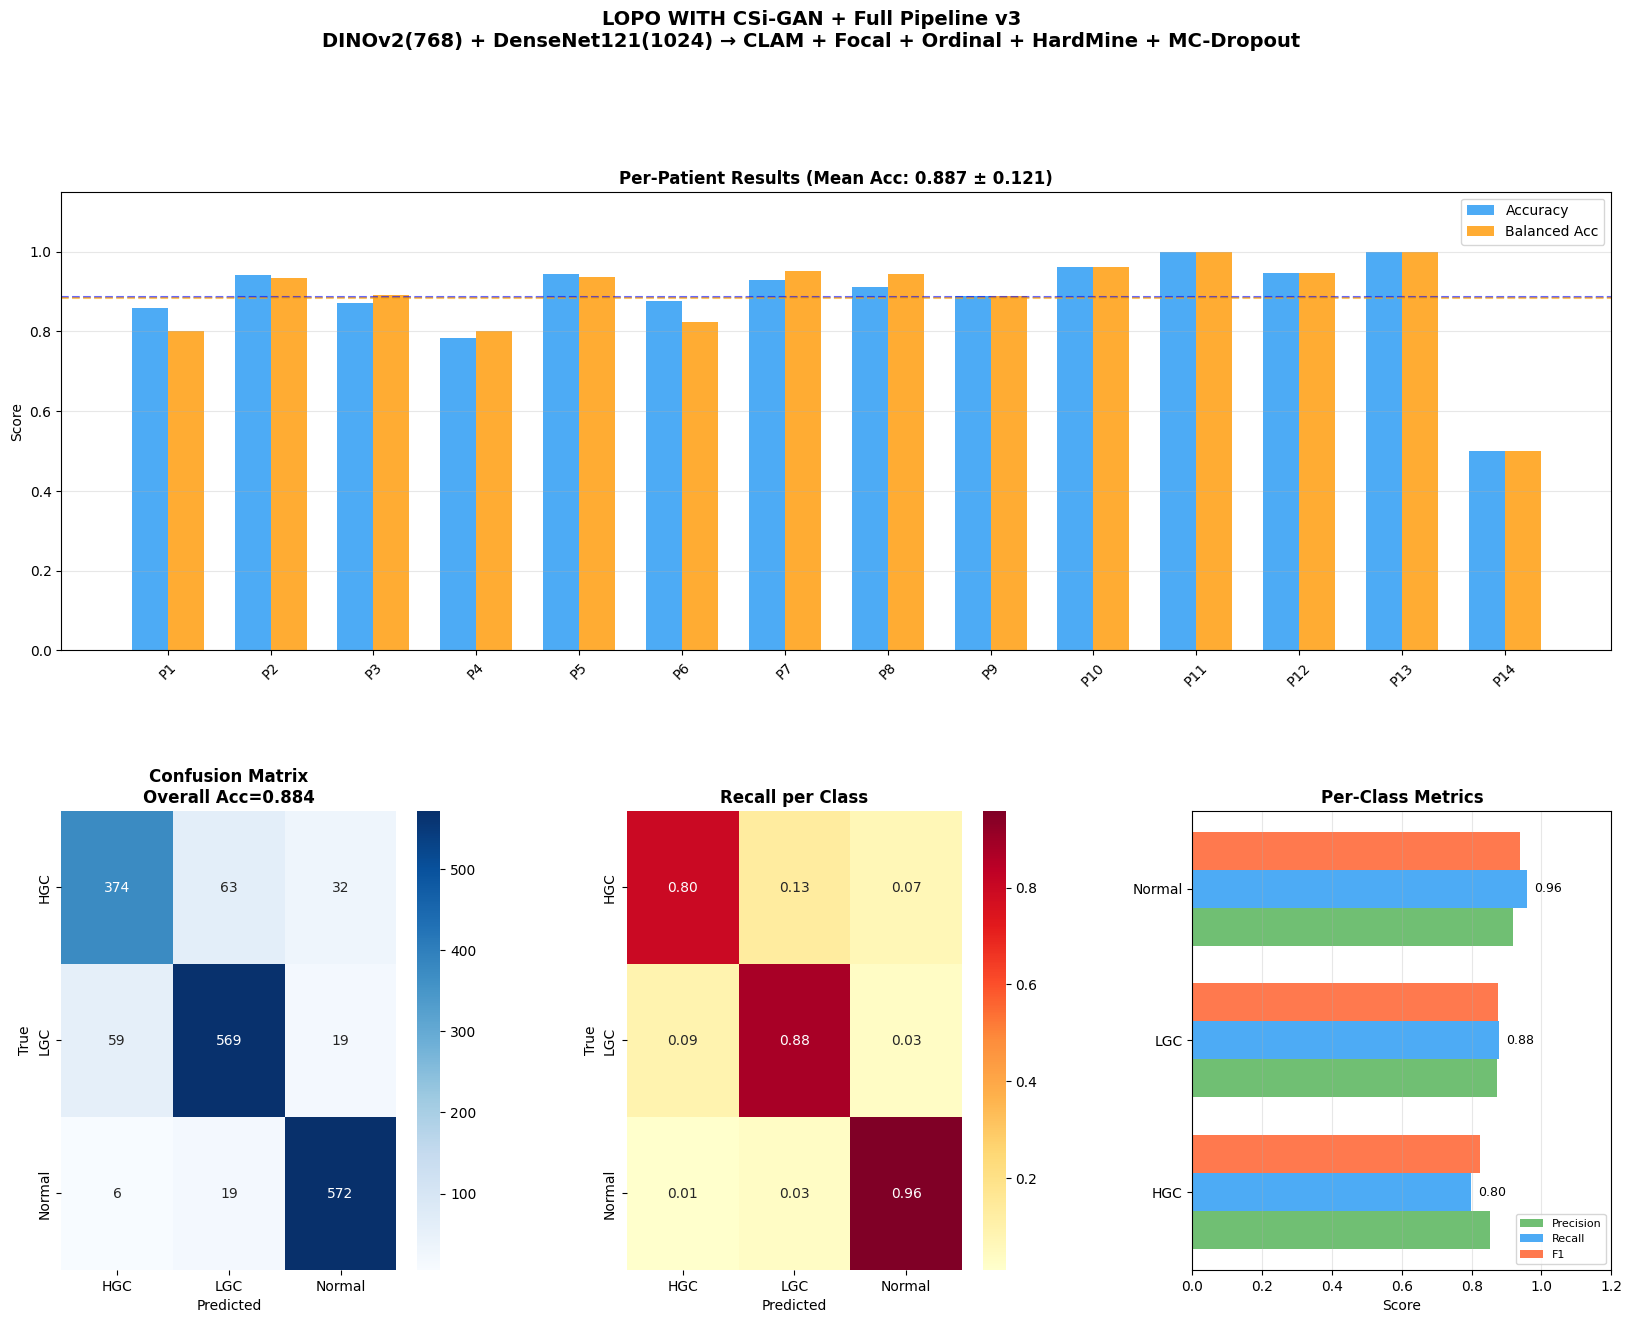

✓ Saved lopo_v3_results.png


In [ ]:
# ============================================================
# CELL 17: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# Per-patient accuracy
ax1 = fig.add_subplot(gs[0, :])
pids = [f"P{f['patient']}" for f in results['folds']]
accs = [f['image_accuracy'] for f in results['folds']]
bals = [f['balanced_accuracy'] for f in results['folds']]
x = np.arange(len(pids)); w = 0.35
ax1.bar(x - w/2, accs, w, color='#2196F3', alpha=0.8, label='Accuracy')
ax1.bar(x + w/2, bals, w, color='#FF9800', alpha=0.8, label='Balanced Acc')
ax1.set_ylabel('Score')
ax1.set_title(f'Per-Patient Results (Mean Acc: {results["mean_patient_accuracy"]:.3f} '
              f'± {results["std_patient_accuracy"]:.3f})', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(pids, rotation=45)
ax1.set_ylim(0, 1.15); ax1.grid(axis='y', alpha=0.3)
ax1.axhline(results['mean_patient_accuracy'], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
ax1.axhline(results['mean_patient_balanced'], color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
ax1.legend()

# Confusion matrix
ax2 = fig.add_subplot(gs[1, 0])
cm = np.array(results['overall_confusion'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax2)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title(f'Confusion Matrix\nOverall Acc={results["overall_image_accuracy"]:.3f}', fontweight='bold')

# Normalized confusion
ax3 = fig.add_subplot(gs[1, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax3)
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
ax3.set_title('Recall per Class', fontweight='bold')

# Per-class metrics
ax4 = fig.add_subplot(gs[1, 2])
recalls, precisions, f1s = [], [], []
for i in range(CFG.num_classes):
    rs = cm[i].sum(); cs = cm[:, i].sum()
    r = cm[i,i] / max(rs, 1); p = cm[i,i] / max(cs, 1)
    recalls.append(r); precisions.append(p)
    f1s.append(2*p*r / max(p+r, 1e-8))
y_pos = np.arange(CFG.num_classes); bw = 0.25
ax4.barh(y_pos - bw, precisions, bw, color='#4CAF50', alpha=0.8, label='Precision')
ax4.barh(y_pos,      recalls,    bw, color='#2196F3', alpha=0.8, label='Recall')
ax4.barh(y_pos + bw, f1s,        bw, color='#FF5722', alpha=0.8, label='F1')
for i in range(CFG.num_classes):
    ax4.text(recalls[i]+0.02, i, f'{recalls[i]:.2f}', va='center', fontsize=9)
ax4.set_yticks(y_pos); ax4.set_yticklabels(CFG.class_names)
ax4.set_xlabel('Score'); ax4.set_title('Per-Class Metrics', fontweight='bold')
ax4.set_xlim(0, 1.2); ax4.grid(axis='x', alpha=0.3); ax4.legend(fontsize=8)

fig.suptitle(
    f'LOPO WITH CSi-GAN + Full Pipeline v3\n'
    f'{backbone_desc} → CLAM + Focal + Ordinal + HardMine + MC-Dropout',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('lopo_v3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved lopo_v3_results.png")

In [ ]:
# ============================================================
# CELL 18: EXPORT RESULTS
# ============================================================

def to_serialisable(obj):
    if isinstance(obj, (np.integer,)):   return int(obj)
    if isinstance(obj, (np.floating,)):  return float(obj)
    if isinstance(obj, np.ndarray):      return obj.tolist()
    return obj

summary = {
    'pipeline': f'Lab_Norm + MultiScale + {backbone_desc} + CLAM(v3)',
    'evaluation': 'LOPO',
    'augmentation': True,
    'improvements': [
        'focal_loss_gamma_3.0',
        'hierarchical_cancer_vs_normal',
        'ordinal_severity_loss',
        'feature_mixup',
        'class_balanced_sampling',
        'two_stage_hard_mining',
        'mc_dropout_inference',
        'confidence_weighted_geo_ensemble',
        'feature_adapter_residual',
        'multi_head_gated_attention',
        'hgc_weight_boost_2.5x',
    ],
    'classes': CFG.class_names,
    'n_patients': N_PATIENTS,
    'total_original_images': len(df),
    'total_augmented_images': len(aug_df),
    'results': {
        'mean_patient_acc':     results['mean_patient_accuracy'],
        'std_patient_acc':      results['std_patient_accuracy'],
        'mean_patient_bal':     results['mean_patient_balanced'],
        'std_patient_bal':      results['std_patient_balanced'],
        'overall_image_acc':    results['overall_image_accuracy'],
        'overall_balanced_acc': results['overall_balanced_accuracy'],
        'total_correct':        results['total_correct'],
        'total_images':         results['total_images'],
        'confusion_matrix':     results['overall_confusion'],
        'folds':                results['folds']
    },
    'config': {
        'patch_scales':           CFG.patch_scales,
        'max_patches_per_image':  CFG.max_patches_per_image,
        'feature_dim':            CFG.feat_dim,
        'backbone':               backbone_desc,
        'mil_model':              'CLAM_v3',
        'focal_gamma':            CFG.focal_gamma,
        'hgc_weight_boost':       CFG.hgc_weight_boost,
        'ordinal_loss_w':         CFG.ordinal_loss_w,
        'hier_loss_w':            CFG.hier_loss_w,
        'epochs_stage1':          CFG.epochs,
        'epochs_stage2':          CFG.hard_mine_epochs,
        'hard_mine_frac':         CFG.hard_mine_frac,
        'patience':               CFG.patience,
        'lr':                     CFG.lr,
        'n_ensemble':             CFG.n_ensemble,
        'balanced_sampling':      CFG.balanced_sampling,
        'mc_dropout':             CFG.use_mc_dropout,
        'tta_rounds':             CFG.tta_rounds,
        'total_runtime_minutes':  total_time / 60
    }
}

with open('results_v3_augmented.json', 'w') as f:
    json.dump(summary, f, indent=2, default=to_serialisable)
print("✓ Saved results_v3_augmented.json")

# Per-patient CSV
rows = []
for f in results['folds']:
    rows.append({
        'patient': f['patient'], 'n_test_images': f['n_test_images'],
        'accuracy': round(f['image_accuracy'], 4),
        'balanced_accuracy': round(f['balanced_accuracy'], 4),
        'confidence': round(f['mean_confidence'], 4),
        'n_aug_train': f['n_aug_train'],
    })
pd.DataFrame(rows).to_csv('fold_results_v3.csv', index=False)
print("✓ Saved fold_results_v3.csv")

# Classification report
with open('classification_report_v3.txt', 'w') as f_out:
    f_out.write(f"FULL PIPELINE v3\n{'='*50}\n\n")
    f_out.write(classification_report(
        results['all_y_true'], results['all_y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))
print("✓ Saved classification_report_v3.txt")

print(f"\n{'='*60}")
print("  EXPERIMENT COMPLETE — FULL PIPELINE v3")
print(f"{'='*60}")
print(f"  Mean Patient Accuracy : {results['mean_patient_accuracy']:.4f} "
      f"± {results['std_patient_accuracy']:.4f}")
print(f"  Overall Image Accuracy: {results['overall_image_accuracy']:.4f}")
print(f"  Overall Balanced Acc  : {results['overall_balanced_accuracy']:.4f}")
print(f"  Runtime               : {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
print(f"{'='*60}\n")

✓ Saved results_v3_augmented.json
✓ Saved fold_results_v3.csv
✓ Saved classification_report_v3.txt

  EXPERIMENT COMPLETE — FULL PIPELINE v3
  Mean Patient Accuracy : 0.8866 ± 0.1210
  Overall Image Accuracy: 0.8844
  Overall Balanced Acc  : 0.8783
  Runtime               : 994.2 min (16.6 hours)

